# Retail Supply Chain Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Latex
import warnings

warnings.filterwarnings('ignore')

## Data loading

In [2]:
df = pd.read_excel('../data/Retail-Supply-Chain-Sales-Dataset.xlsx')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.3680,2,0.20,2.5164


In [4]:
print('Dataset shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))

Dataset shape: 9994 rows, 23 columns


## Data cleaning

In [5]:
print('Any duplicates?', df.duplicated().any())

Any duplicates? False


In [6]:
missing_values = df.isna().sum()

print('Missing values: ')
print(missing_values)

Missing values: 
Row ID                 0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Postal Code            0
Region                 0
Retail Sales People    0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Returned               0
Sales                  0
Quantity               0
Discount               0
Profit                 0
dtype: int64


In [7]:
df.drop(columns='Row ID', inplace=True)

### Exploratory Data Analysis

In [8]:
df.dtypes

Order ID                       object
Order Date             datetime64[ns]
Ship Date              datetime64[ns]
Ship Mode                      object
Customer ID                    object
Customer Name                  object
Segment                        object
Country                        object
City                           object
State                          object
Postal Code                     int64
Region                         object
Retail Sales People            object
Product ID                     object
Category                       object
Sub-Category                   object
Product Name                   object
Returned                       object
Sales                         float64
Quantity                        int64
Discount                      float64
Profit                        float64
dtype: object

In [9]:
numerical_cols = df[['Sales', 'Quantity', 'Profit']]

numerical_cols.describe()

,Sales,Quantity,Profit
count,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,28.656896
std,623.245101,2.225110,234.260108
min,0.444000,1.000000,-6599.978000
25%,17.280000,2.000000,1.728750
50%,54.490000,3.000000,8.666500
75%,209.940000,5.000000,29.364000
max,22638.480000,14.000000,8399.976000


In [10]:
# It can only be assumed that profit is a lot lower than expected due to losses

In [11]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print(categorical_columns)

['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Retail Sales People', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Returned']


In [12]:
for i in ['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category', 'Returned']:
    line = "**" + i + ":** "
    for j in df[i].unique():
        line = line + str(j) + ", "
        
    line = line[:-2]
    display(Markdown(line))

**Ship Mode:** Second Class, Standard Class, First Class, Same Day

**Segment:** Consumer, Corporate, Home Office

**Country:** United States

**Region:** South, West, Central, East

**Category:** Furniture, Office Supplies, Technology

**Sub-Category:** Bookcases, Chairs, Labels, Tables, Storage, Furnishings, Art, Phones, Binders, Appliances, Paper, Accessories, Envelopes, Fasteners, Supplies, Machines, Copiers

**Returned:** Not, Yes

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


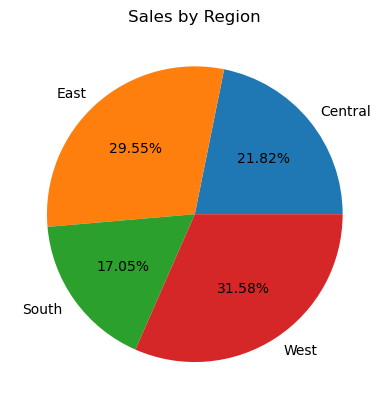

In [14]:
plt.figure()

plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.2f%%')
plt.title('Sales by Region')
plt.show()

In [15]:
# Sales are nicely spread out across the regions

In [16]:
pd.set_option('display.max_colwidth', None)

In [17]:
df.groupby('Category')['Sub-Category'].unique().reset_index()

,Category,Sub-Category
0,Furniture,"[Bookcases, Chairs, Tables, Furnishings]"
1,Office Supplies,"[Labels, Storage, Art, Binders, Appliances, Paper, Envelopes, Fasteners, Supplies]"
2,Technology,"[Phones, Accessories, Machines, Copiers]"


In [18]:
# The retail business focuses on furniture, office supplies, and tech products, with more sub-categories in office supplies

In [19]:
df.groupby('Sub-Category')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders', ascending=False)

,Sub-Category,Total Orders
3,Binders,1523
12,Paper,1370
9,Furnishings,957
13,Phones,889
14,Storage,846
2,Art,796
0,Accessories,775
5,Chairs,617
1,Appliances,466
10,Labels,364


In [20]:
print('Top 10 total orders by product name:')

df.groupby('Product Name')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders', ascending=False).head(10)

Top 10 total orders by product name:


,Product Name,Total Orders
1493,Staple envelope,48
1499,Staples,46
537,Easy-staple paper,46
259,Avery Non-Stick Binders,20
1500,Staples in misc. colors,19
1496,Staple remover,18
942,KI Adjustable-Height Table,18
1511,Storex Dura Pro Binders,17
1497,Staple-based wall hangings,16
993,Logitech 910-002974 M325 Wireless Mouse for Web Scrolling,15


In [21]:
# The sub-categories of binders, paper, and furnishings show a significant number of sales by order from customers
# Staple products seem to be ordered the most from customers

In [22]:
print('Bottom 10 total orders by product name:')

df.groupby('Product Name')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders').head(10)

Bottom 10 total orders by product name:


,Product Name,Total Orders
1227,Panasonic Business Telephones KX-T7736,1
1215,Okidata B401 Printer,1
175,Avaya IP Phone 1140E VoIP phone,1
656,"Fellowes Smart Surge Ten-Outlet Protector, Platinum",1
1225,PNY Rapid USB Car Charger - Black,1
1686,Xerox 1901,1
191,Avery 484,1
1703,Xerox 1918,1
1234,Panasonic KX MB2061 Multifunction Printer,1
1245,Park Ridge Embossed Executive Business Envelopes,1


In [23]:
df.groupby('Category')['Order ID'].count().reset_index().rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Total Orders')

,Category,Total Orders
2,Technology,1847
0,Furniture,2121
1,Office Supplies,6026


In [24]:
# Tech products are sold the least

In [25]:
products_sales_top_10 = df.groupby('Product Name')['Sales'].sum().reset_index().rename(columns={'Sales': 'Total Amount'}).sort_values(by='Total Amount', ascending=False).head(10)

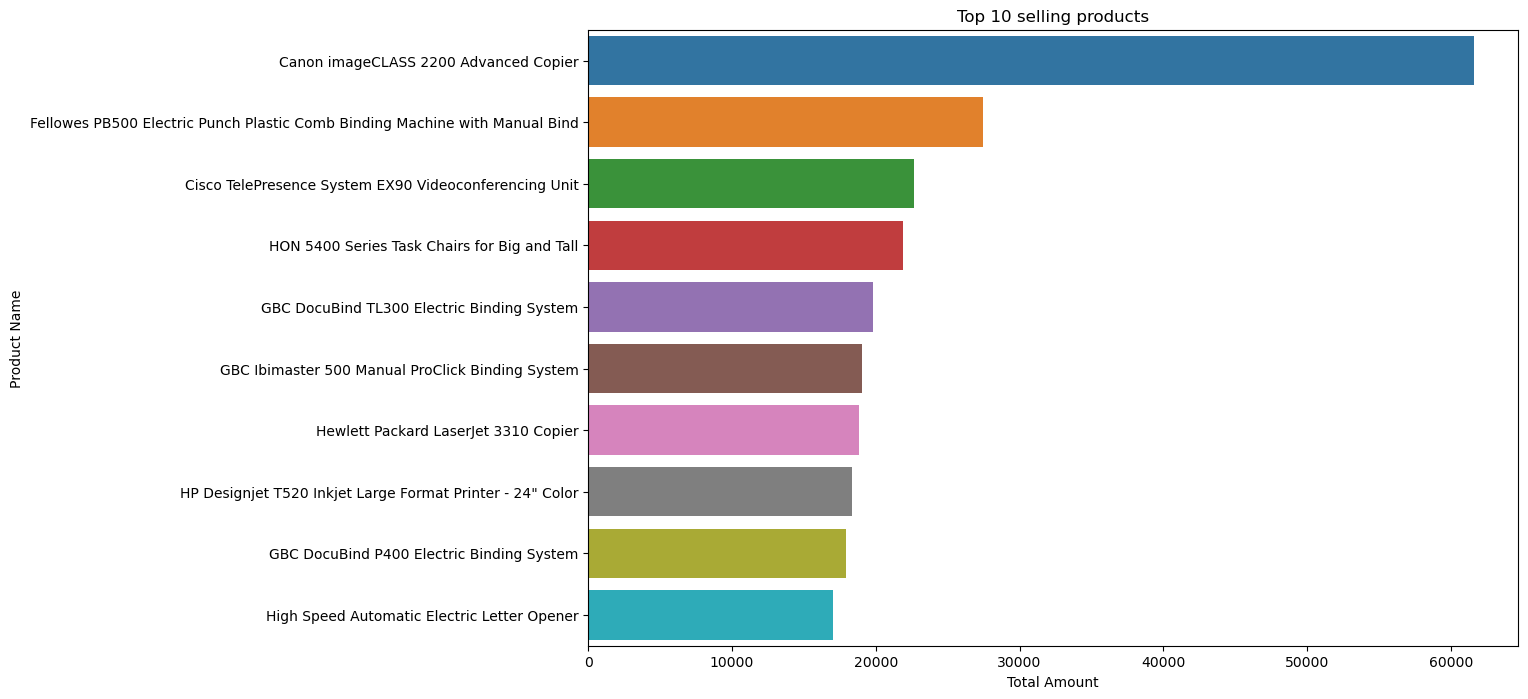

In [26]:
plt.figure(figsize=(12,8))

ax = sns.barplot(products_sales_top_10, x='Total Amount', y='Product Name')
plt.title('Top 10 selling products')
plt.show()

In [27]:
# Tech products sell less, but they sell for a big amount
# Total amount/revenue seems good, but the question remains of why the average profit is so low

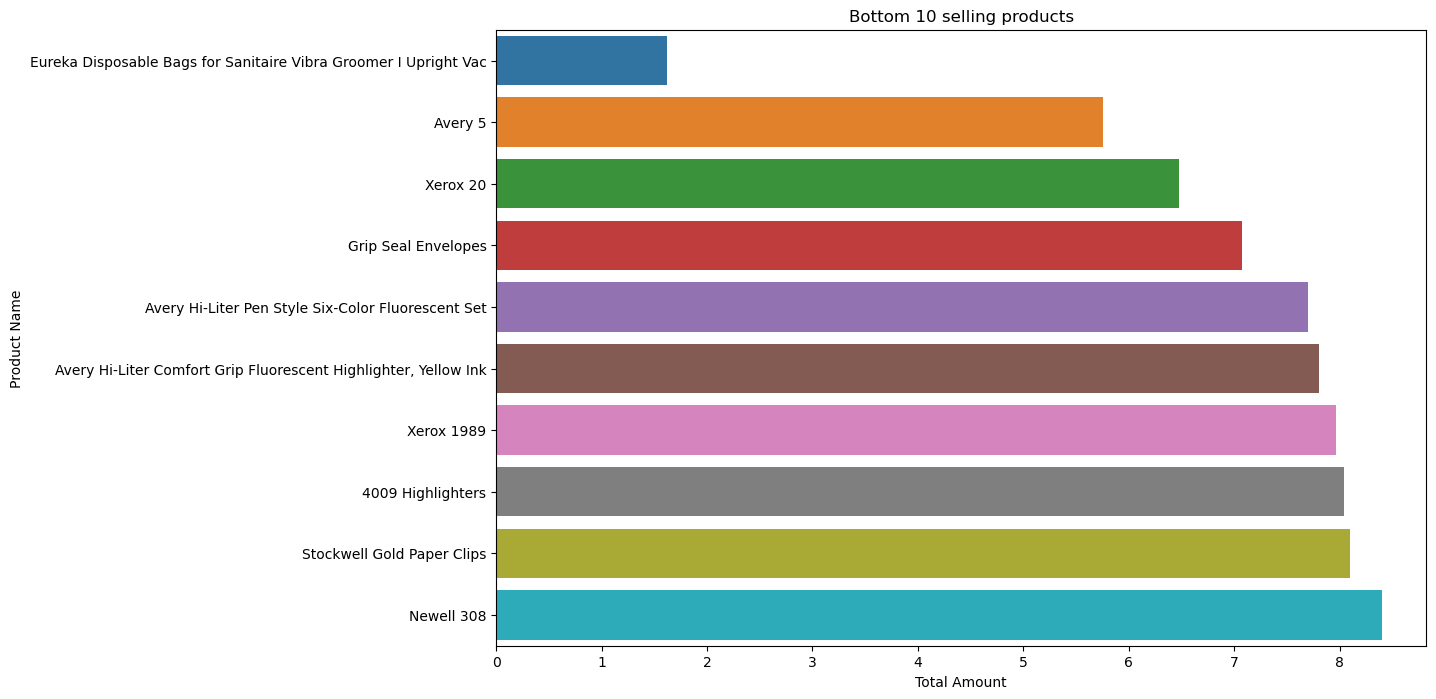

In [28]:
products_sales_bottom_10 = df.groupby('Product Name')['Sales'].sum().reset_index().rename(columns={'Sales': 'Total Amount'}).sort_values(by='Total Amount').head(10)

plt.figure(figsize=(12,8))

ax = sns.barplot(products_sales_bottom_10, x='Total Amount', y='Product Name')
plt.title('Bottom 10 selling products')
plt.show()

In [29]:
products_profit_top_10 = df.groupby('Product Name')['Profit'].sum().reset_index().sort_values(by='Profit', ascending=False).head(10)

products_profit_top_10

,Product Name,Profit
404,Canon imageCLASS 2200 Advanced Copier,25199.9280
650,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
805,Hewlett Packard LaserJet 3310 Copier,6983.8836
400,Canon PC1060 Personal Laser Copier,4570.9347
787,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
165,Ativa V4110MDD Micro-Cut Shredder,3772.9461
19,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
1276,Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
895,Ibico EPK-21 Electric Binding System,3345.2823
1840,Zebra ZM400 Thermal Label Printer,3343.5360


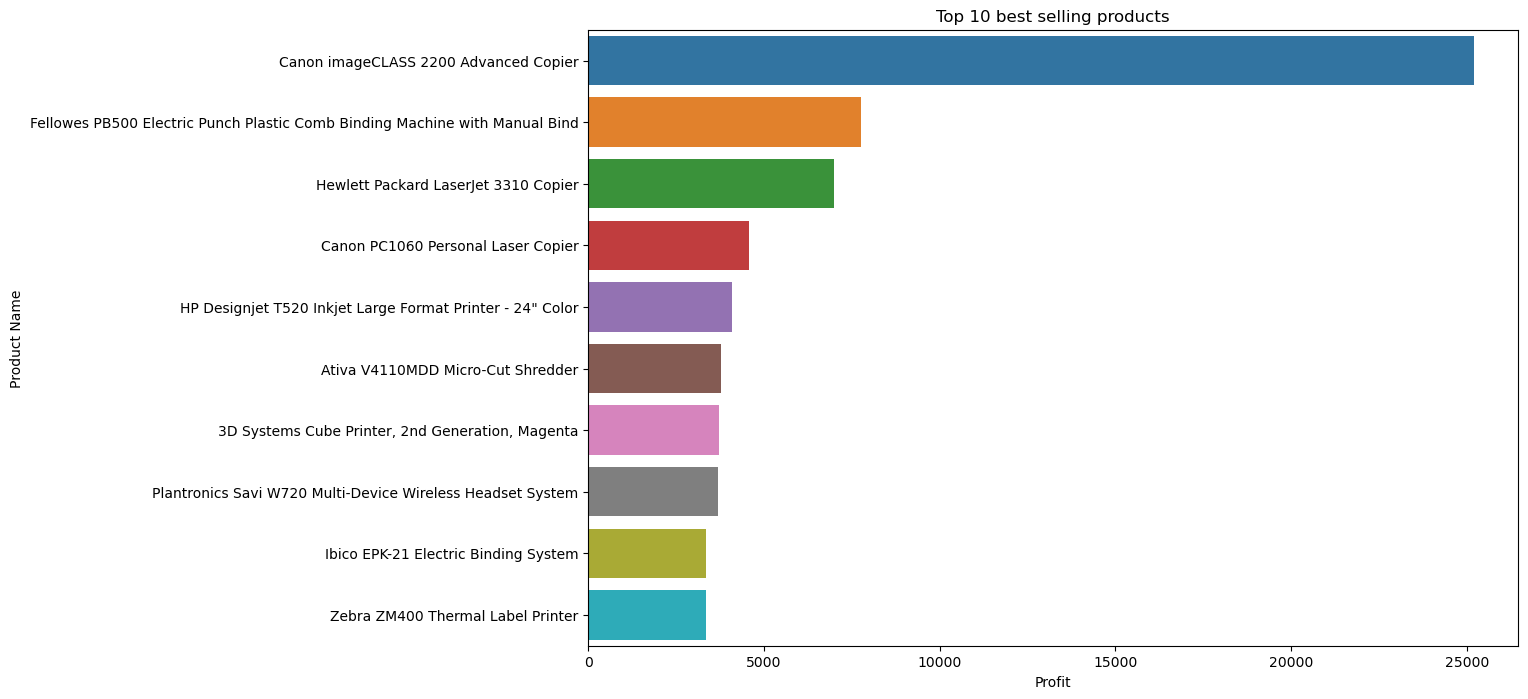

In [30]:
plt.figure(figsize=(12,8))

ax = sns.barplot(products_profit_top_10, x='Profit', y='Product Name')
plt.title('Top 10 best selling products')
plt.show()

In [31]:
products_profit_bottom_10 = df.groupby('Product Name')['Profit'].sum().reset_index().sort_values(by='Profit').head(10)

products_profit_bottom_10

,Product Name,Profit
475,Cubify CubeX 3D Printer Double Head Print,-8879.9704
985,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
476,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
425,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
376,Bush Advantage Collection Racetrack Conference Table,-1934.3976
683,GBC DocuBind P400 Electric Binding System,-1878.1662
444,Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
1043,Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
285,Balt Solid Wood Round Tables,-1201.0581
364,BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,-1148.4375


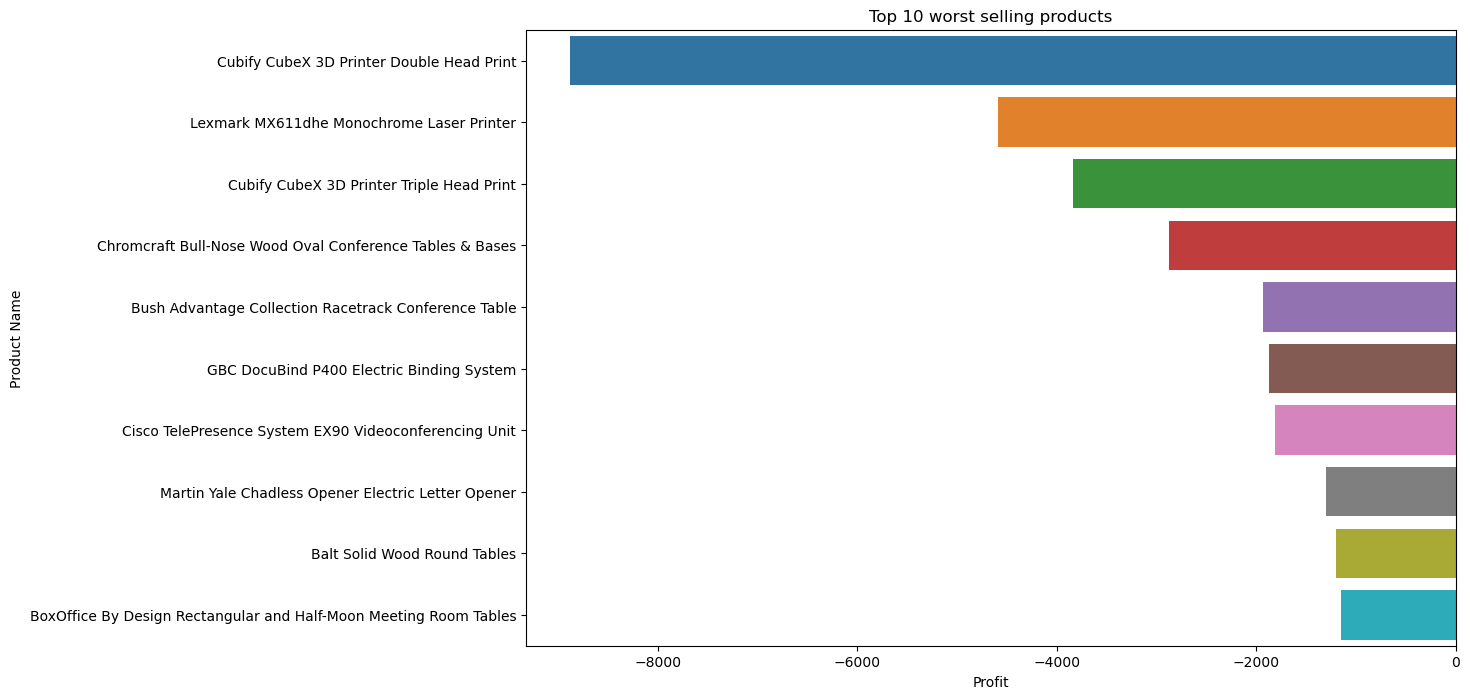

In [32]:
plt.figure(figsize=(12,8))

ax = sns.barplot(products_profit_bottom_10, x='Profit', y='Product Name')
plt.title('Top 10 worst selling products')
plt.show()

In [33]:
# There are some tech products that are causing huge losses, either because they are being returned or they are being discounted

In [34]:
returned_products = df[df['Returned'] == 'Yes'].groupby('Sub-Category')['Returned'].count().reset_index().sort_values(by='Returned', ascending=False)

returned_products

,Sub-Category,Returned
3,Binders,137
12,Paper,123
13,Phones,77
9,Furnishings,72
0,Accessories,61
14,Storage,57
5,Chairs,53
2,Art,47
1,Appliances,40
16,Tables,30


In [35]:
return_rate = (df[df['Returned'] == 'Yes'].groupby('Sub-Category')['Returned'].count() / df.groupby('Sub-Category')['Returned'].count() * 100).reset_index().rename(columns={'Returned': '% returned'}).sort_values(by='% returned', ascending=False)

return_rate

,Sub-Category,% returned
11,Machines,11.304348
16,Tables,9.404389
3,Binders,8.995404
12,Paper,8.978102
8,Fasteners,8.755760
13,Phones,8.661417
5,Chairs,8.589951
1,Appliances,8.583691
15,Supplies,8.421053
0,Accessories,7.870968


In [36]:
# The first part only counted the absolute value, so that is the reason why Binders was on top, but upon calculating the percentage rate relative to total orders, it tells a different story
# It confirms the initial assumption that tech products, despite selling less but also generating a lot of revenue, are also being returned the most, at 11.3% return rate

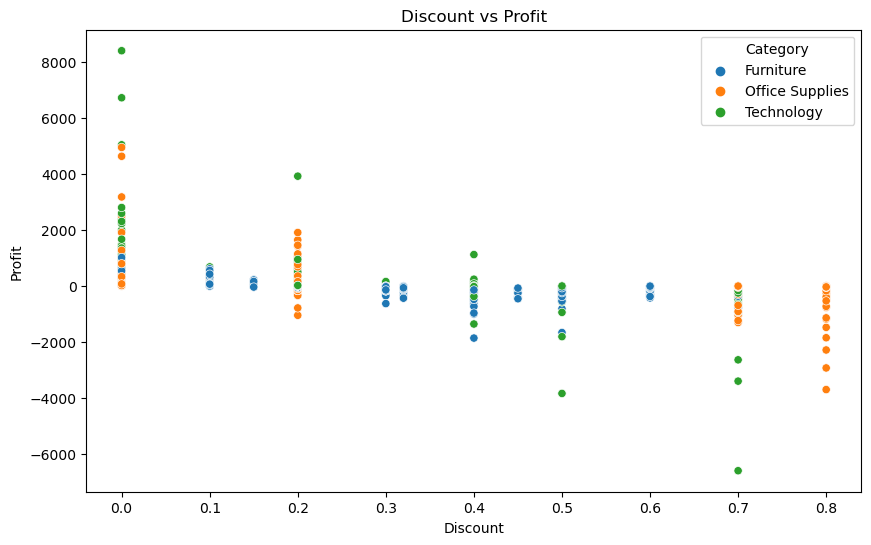

In [37]:
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title('Discount vs Profit')
plt.show()

In [38]:
# There are products being discounted at above 0.25, which should it make it harder to break even. 
# Some office supplies are being discounted at 80%
# Some technology products are being discounted between 30% and 70%, which is very high

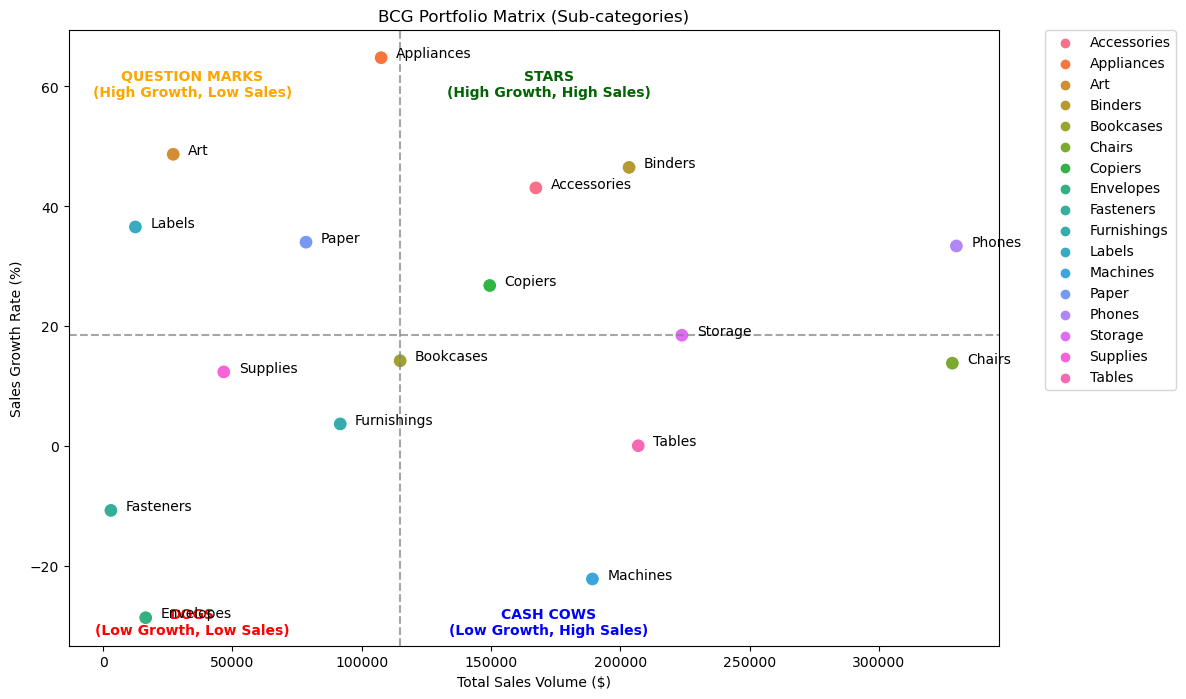

In [39]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df ['Order Date'].dt.year

sales_by_year = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()

last_year = sales_by_year.columns[-1]
prev_year = sales_by_year.columns[-2]
sales_by_year['Growth_Rate'] = ((sales_by_year[last_year] - sales_by_year[prev_year]) / sales_by_year[prev_year]) * 100

total_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()

bcg_df = pd.merge(total_sales, sales_by_year['Growth_Rate'], on='Sub-Category')

x_mid = bcg_df['Sales'].median()
y_mid = bcg_df['Growth_Rate'].median()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=bcg_df, x='Sales', y='Growth_Rate', hue='Sub-Category', s=100)

plt.axvline(x=x_mid, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=y_mid, color='gray', linestyle='--', alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.text(x_mid * 1.5, bcg_df['Growth_Rate'].max() * 0.9, 'STARS\n(High Growth, High Sales)', color='darkgreen', weight='bold', ha='center')
plt.text(x_mid * 1.5, bcg_df['Growth_Rate'].min() * 1.1, 'CASH COWS\n(Low Growth, High Sales)', color='blue', weight='bold', ha='center')
plt.text(x_mid * 0.3, bcg_df['Growth_Rate'].max() * 0.9, 'QUESTION MARKS\n(High Growth, Low Sales)', color='orange', weight='bold', ha='center')
plt.text(x_mid * 0.3, bcg_df['Growth_Rate'].min() * 1.1, 'DOGS\n(Low Growth, Low Sales)', color='red', weight='bold', ha='center')

for i in range(bcg_df.shape[0]):
    plt.text(bcg_df.Sales[i] + (x_mid * 0.05), bcg_df.Growth_Rate[i], bcg_df['Sub-Category'][i], horizontalalignment='left', size='medium', color='black')
    
plt.title('BCG Portfolio Matrix (Sub-categories)')
plt.xlabel('Total Sales Volume ($)')
plt.ylabel('Sales Growth Rate (%)')
plt.show()

In [40]:
# A BCG portfolio shows where the sub-categories would fit.
# Stars are the flagship products, which means they are in high demand and generate a lot of revenue
# Cash cows are the mature products where the growth for it has slowed down, but they generate a steady revenue
# Question marks are sort of the wildcards where the growth is high, but low sales
# Dogs are the stagnant products and these are not that good as they occupy inventory

# In this case, the business needs to focus more on the stars, and also question marks that could be turned into stars if played right
# Sub-Categories such as Art, Paper, Binder, Copiers and so forth should be invested into heavily
# The sub-categories in the dog quadrant should be dealt with more consideration to see if any of these can be turned into stars
# Cash cows should also be invested in to some extent, given that they generate a lor of revenue for the business